In [1]:
# %% [markdown]
# # Task 1: Data Exploration and Preprocessing
# This notebook explores the GSE40279 dataset and establishes the preprocessing pipeline.

# %%
!pip install matplotlib seaborn pandas scikit-learn
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add src to path to import functions
sys.path.append('../src/')
from functions import load_dataset, split_data, get_preprocessing_pipeline

# %% [markdown]
# ## 1.1 Data Loading and Splitting
# Loading the development set and splitting it into 80% training and 20% validation.

# %%
df_dev = load_dataset('/Users/giorgos.boulogeorgos/Documents/mlcb_assignment1/data/development_data.csv')
train_df, val_df = split_data(df_dev, target_col='age', test_size=0.2, seed=42)

print(f"Full Dev Set: {df_dev.shape}")
print(f"Training Set: {train_df.shape}")
print(f"Validation Set: {val_df.shape}")



Full Dev Set: (456, 1004)
Training Set: (364, 1004)
Validation Set: (92, 1004)


/Users/giorgos.boulogeorgos/Documents/mlcb_assignment1/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Deliverable: Dataset Statistics Table ---


,Split,n,Age (Mean ± STD),Sex Balance (% Female)
0,Full Development,456,64.45 ± 14.63,49.1%
1,Training (80%),364,64.26 ± 14.64,48.4%
2,Validation (20%),92,65.21 ± 14.67,52.2%


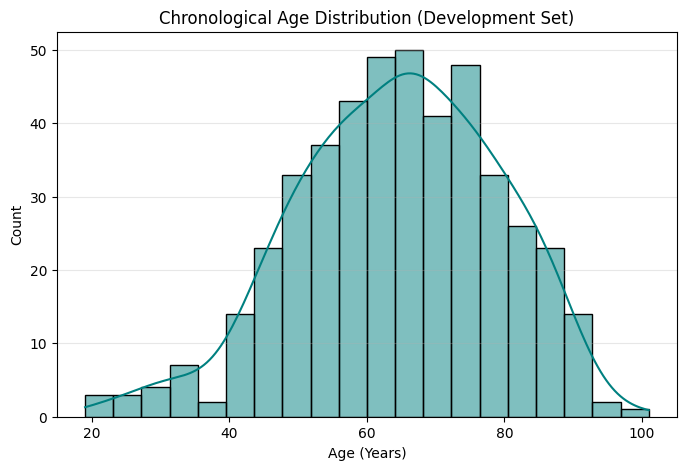

Metadata Matrix Shape: (364, 4)
CpG Matrix Shape: (364, 1000)
Combined Matrix Shape: (364, 1004)


In [2]:
# %% [markdown]
# ## 1.3 Exploratory Analysis
# Generating dataset dimensions, age distribution, and sex balance.

# %%
# Table 1: Dataset Statistics Deliverable
stats_data = {
    "Split": ["Full Development", "Training (80%)", "Validation (20%)"],
    "n": [len(df_dev), len(train_df), len(val_df)],
    "Age (Mean ± STD)": [
        f"{df_dev['age'].mean():.2f} ± {df_dev['age'].std():.2f}",
        f"{train_df['age'].mean():.2f} ± {train_df['age'].std():.2f}",
        f"{val_df['age'].mean():.2f} ± {val_df['age'].std():.2f}"
    ],
    "Sex Balance (% Female)": [
        f"{(df_dev['sex'] == 'F').mean()*100:.1f}%",
        f"{(train_df['sex'] == 'F').mean()*100:.1f}%",
        f"{(val_df['sex'] == 'F').mean()*100:.1f}%"
    ]
}
stats_table = pd.DataFrame(stats_data)
print("--- Deliverable: Dataset Statistics Table ---")
display(stats_table)

# Age Distribution Visualization
plt.figure(figsize=(8, 5))
sns.histplot(df_dev['age'], bins=20, kde=True, color='teal')
plt.title('Chronological Age Distribution (Development Set)')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.savefig('../figures/age_distribution.png', dpi=150)
plt.show()

# %% [markdown]
# ## 1.2 Preprocessing & Feature Matrices
# Constructing different feature sets to evaluate predictive signals.

# %%
cpg_cols = [col for col in df_dev.columns if col.startswith('cg')]
meta_cols = ['sex', 'ethnicity']

# Initialize Pipeline
preprocessor = get_preprocessing_pipeline(cpg_cols, meta_cols)

# Fit on Training, Transform both
X_train_all = preprocessor.fit_transform(train_df)
X_val_all = preprocessor.transform(val_df)

# Extract feature names for subsetting
# Note: OneHotEncoder expands 'sex' and 'ethnicity' into multiple columns
feature_names = preprocessor.get_feature_names_out()

def get_subsets(X, names):
    # CpG features start with 'num__cg' due to pipeline naming
    cpg_idx = [i for i, n in enumerate(names) if 'cg' in n]
    meta_idx = [i for i, n in enumerate(names) if 'cat__' in n]
    return X[:, meta_idx], X[:, cpg_idx], X

# Construct the matrices required for Task 2 baselines 
X_train_meta, X_train_cpg, X_train_combined = get_subsets(X_train_all, feature_names)
X_val_meta, X_val_cpg, X_val_combined = get_subsets(X_val_all, feature_names)

print(f"Metadata Matrix Shape: {X_train_meta.shape}")
print(f"CpG Matrix Shape: {X_train_cpg.shape}")
print(f"Combined Matrix Shape: {X_train_combined.shape}")